In [1]:
!pip install faiss-cpu -q
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import faiss

BASE_DIR = "homeworks/HW14"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

print("Imports and seed configured")
print("FAISS installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.4 MB/s eta 0:00:00
Imports and seed configured
FAISS installed successfully


In [2]:
knowledge_base = [
    {
        "id": 1,
        "title": "Что такое цифровой маркетинг?",
        "content": "Цифровой маркетинг — это комплекс стратегий продвижения товаров и услуг с использованием цифровых каналов: поисковых систем, социальных сетей, электронной почты, мобильных приложений и веб-сайтов. В отличие от традиционного маркетинга, цифровой позволяет точно измерять эффективность кампаний в реальном времени, таргетировать аудиторию по демографии, интересам и поведению, а также оперативно оптимизировать рекламные бюджеты. Основные направления включают SEO, контент-маркетинг, контекстную рекламу, SMM, email-маркетинг и аналитику. Успешная стратегия цифрового маркетинга строится на глубоком понимании целевой аудитории, четких бизнес-целях и постоянном тестировании гипотез для достижения максимальной конверсии и ROI."
    },
    {
        "id": 2,
        "title": "Как работает поисковая оптимизация (SEO)?",
        "content": "SEO (Search Engine Optimization) — это процесс улучшения видимости сайта в органических результатах поисковых систем, таких как Яндекс и Google. Оптимизация делится на три ключевых направления: техническое (скорость загрузки, мобильная адаптация, структура URL), внутреннее (качественный контент, мета-теги, заголовки, внутренняя перелинковка) и внешнее (получение авторитетных обратных ссылок). Поисковые системы используют сложные алгоритмы, учитывающие более 200 факторов ранжирования, включая релевантность контента запросу, поведенческие метрики пользователей и доверие к домену. Регулярный аудит, обновление контента и соответствие требованиям поисковиков помогают удерживать и улучшать позиции сайта в выдаче, привлекая целевой трафик без прямых затрат на клик."
    },
    {
        "id": 3,
        "title": "Что такое контент-маркетинг и зачем он нужен?",
        "content": "Контент-маркетинг — это стратегия создания и распространения ценного, релевантного и последовательного контента для привлечения и удержания четко определенной аудитории с целью стимулирования прибыльных действий клиентов. В отличие от прямой рекламы, контент-маркетинг строит доверие и экспертный статус бренда через образовательные статьи, видео, инфографику, подкасты и кейсы. Эффективный контент отвечает на вопросы целевой аудитории на разных этапах воронки продаж: от осведомленности до принятия решения. Ключевые метрики успеха включают время на странице, глубину просмотра, количество лидов и конверсий, а также рост органического трафика и социального вовлечения."
    },
    {
        "id": 4,
        "title": "Как настроить контекстную рекламу в Яндекс.Директ?",
        "content": "Настройка контекстной рекламы в Яндекс.Директ начинается с определения целей кампании: трафик, конверсии, охват или продажи. Далее необходимо провести семантический анализ и собрать релевантные ключевые слова, разделив их на группы по тематике и намерению пользователя. Для каждой группы создаются объявления с цепляющими заголовками, четкими УТП и призывами к действию, а также настраиваются минус-слова для исключения нерелевантных показов. Важными элементами являются выбор стратегии ставок (ручная или автоматическая), настройка геотаргетинга, временного таргетинга и ретаргетинга, а также подключение метрики для отслеживания конверсий. Регулярная оптимизация на основе аналитики позволяет снижать стоимость клика и повышать ROI рекламных вложений."
    },
    {
        "id": 5,
        "title": "Как эффективно использовать социальные сети для бизнеса?",
        "content": "Эффективное использование социальных сетей для бизнеса требует стратегического подхода: выбора подходящих платформ под целевую аудиторию (ВКонтакте, Telegram, Instagram*, YouTube), разработки контент-плана с балансом продающих, образовательных и развлекательных материалов, и активного взаимодействия с подписчиками. Важно адаптировать формат контента под особенности каждой площадки: короткие видео для Reels и Shorts, длинные посты для ВКонтакте, экспертные статьи для Дзена. Регулярная аналитика вовлеченности, охватов и конверсий помогает корректировать стратегию. Дополнительные возможности включают таргетированную рекламу, коллаборации с блогерами, проведение конкурсов и использование чат-ботов для автоматизации коммуникации с клиентами."
    },
    {
        "id": 6,
        "title": "Что такое email-маркетинг и как его автоматизировать?",
        "content": "Email-маркетинг — это инструмент прямого взаимодействия с аудиторией через персонализированные рассылки, направленные на информирование, вовлечение и конвертацию подписчиков в клиентов. Эффективность зависит от качества базы (сбор через лид-магниты, двойное подтверждение), сегментации аудитории по поведению и интересам, а также релевантности контента. Автоматизация позволяет настраивать триггерные цепочки: приветственные серии, напоминания о брошенной корзине, реактивацию неактивных пользователей. Платформы вроде SendPulse, UniSender или Mailchimp предоставляют конструкторы писем, A/B-тестирование, аналитику открытий и кликов. Соблюдение законодательства (ФЗ-152, GDPR) и предоставление возможности отписки — обязательные условия для легальной работы."
    },
    {
        "id": 7,
        "title": "Как анализировать эффективность маркетинговых кампаний?",
        "content": "Анализ эффективности маркетинговых кампаний строится на системе метрик, соответствующих поставленным целям: для трафика — CTR, стоимость клика; для вовлечения — время на сайте, глубина просмотра; для конверсий — CR, CPA, ROI. Инструменты веб-аналитики (Яндекс.Метрика, Google Analytics) позволяют отслеживать пользовательские пути, настраивать цели и воронки, сегментировать аудиторию. Важно использовать UTM-метки для точной атрибуции источников трафика и проводить сквозную аналитику, связывая маркетинговые затраты с выручкой. Регулярные отчеты, дашборды и гипотезы для A/B-тестов помогают оптимизировать бюджет, отказываясь от неэффективных каналов и масштабируя успешные тактики."
    },
    {
        "id": 8,
        "title": "Что такое воронка продаж и как её оптимизировать?",
        "content": "Воронка продаж — это модель, описывающая путь клиента от первого контакта с брендом до совершения покупки и повторных заказов. Классические этапы: осведомленность (awareness), интерес (interest), рассмотрение (consideration), решение (decision), удержание (retention). Оптимизация воронки начинается с аудита каждого этапа: анализ источников трафика, качества лендингов, удобства оформления заказа, работы службы поддержки. Инструменты оптимизации включают ускорение загрузки страниц, упрощение форм, добавление социальных доказательств (отзывы, кейсы), персонализацию предложений и ретаргетинг. Регулярное тестирование гипотез (A/B-тесты заголовков, кнопок, изображений) и анализ поведенческой аналитики позволяют последовательно повышать конверсию на каждом этапе."
    },
    {
        "id": 9,
        "title": "Как создать эффективный лендинг для конверсии?",
        "content": "Эффективный лендинг — это одностраничный сайт, сфокусированный на одном целевом действии: заявка, покупка, подписка. Ключевые элементы: цепляющий заголовок с УТП, подзаголовок с уточнением выгоды, визуальный контент (фото/видео продукта), список преимуществ, социальные доказательства (отзывы, логотипы клиентов), призыв к действию (CTA) с контрастной кнопкой, минималистичная форма захвата. Важны техническая оптимизация (скорость загрузки <2 сек, мобильная адаптация), доверительные элементы (гарантии, сертификаты) и отсутствие отвлекающих ссылок. Тестирование разных версий заголовков, изображений и текстов кнопок через A/B-тесты помогает найти оптимальную комбинацию для максимальной конверсии."
    },
    {
        "id": 10,
        "title": "Что такое таргетированная реклама и как её настроить?",
        "content": "Таргетированная реклама — это показ рекламных объявлений строго определенной аудитории на основе демографии, интересов, поведения и геолокации. Платформы ВКонтакте, MyTarget, Telegram Ads предлагают гибкие настройки: возраст, пол, город, образование, интересы, устройства, а также ретаргетинг посетителей сайта или пользователей, взаимодействовавших с брендом. Для запуска кампании необходимо создать креативы (изображения/видео до 15 сек), написать цепляющий текст с призывом, установить бюджет и стратегию ставок (оплата за клик или показ). Важно сегментировать аудиторию, тестировать несколько вариантов объявлений и отслеживать метрики: CTR, CPC, конверсии. Регулярная оптимизация позволяет снижать стоимость лида и повышать качество трафика."
    },
    {
        "id": 11,
        "title": "Как использовать видеомаркетинг для продвижения бренда?",
        "content": "Видеомаркетинг — один из самых вовлекающих форматов цифрового продвижения, включающий обучающие ролики, обзоры продуктов, интервью, сторителлинг и короткие вертикальные видео для соцсетей. Платформы: YouTube (для длинного контента и SEO), Instagram Reels, TikTok, VK Видео (для вирального охвата). Ключ к успеху — первые 3 секунды видео должны цеплять внимание, далее — четкая структура: проблема → решение → призыв. Важно адаптировать формат под площадку (соотношение сторон, длительность, субтитры), оптимизировать заголовки и описания под поисковые запросы, а также использовать аналитику для понимания удержания аудитории. Регулярный выпуск контента и взаимодействие с комментариями усиливают лояльность и охваты."
    },
    {
        "id": 12,
        "title": "Что такое партнёрский маркетинг (аффилиат)?",
        "content": "Партнёрский маркетинг (аффилиат) — это модель сотрудничества, при которой бренд платит партнёрам (веб-мастерам, блогерам, инфлюенсерам) комиссию за привлеченных клиентов или совершенные действия (продажи, регистрации, заявки). Механика: партнёр размещает уникальную реферальную ссылку или промокод, система отслеживает переходы и конверсии, автоматически начисляет вознаграждение. Популярные форматы: обзоры товаров, сравнения, подборки, нативная интеграция в контент. Для запуска программы важно подготовить промо-материалы, установить прозрачные условия выплат, выбрать платформу для трекинга (Admitad, ActionPay) и контролировать качество трафика. Аффилиат позволяет масштабировать продажи с оплатой за результат, минимизируя риски неэффективных вложений."
    },
    {
        "id": 13,
        "title": "Как работать с репутацией бренда в интернете?",
        "content": "Управление репутацией бренда (ORM — Online Reputation Management) включает мониторинг упоминаний в соцсетях, отзовиках, СМИ и поисковой выдаче, оперативное реагирование на негатив и проактивное формирование позитивного контента. Инструменты: Яндекс.Поиск, Google Alerts, Brand Analytics, специализированные сервисы (YouScan, IQBuzz). Стратегия: публикация экспертных статей, кейсов, отзывов реальных клиентов, работа с лидерами мнений. При негативе важно не удалять комментарии, а отвечать конструктивно, предлагать решение проблемы и переводить диалог в приват. Долгосрочно — вытеснение негативных результатов из ТОПа выдачи через создание качественного позитивного контента и техническую оптимизацию собственных ресурсов."
    },
    {
        "id": 14,
        "title": "Что такое мобильный маркетинг и как его реализовать?",
        "content": "Мобильный маркетинг — это продвижение товаров и услуг через мобильные устройства: смартфоны и планшеты, с учетом особенностей пользовательского поведения (короткие сессии, геолокация, push-уведомления). Каналы: мобильная версия сайта или приложение, SMS-рассылки, push-уведомления, реклама в мобильных приложениях и соцсетях, геотаргетинг. Ключевые требования: адаптивный дизайн, скорость загрузки <3 сек, упрощенная навигация и форма заказа. Эффективные тактики: персонализированные предложения по геолокации, триггерные уведомления (напоминания, акции), интеграция с мессенджерами. Аналитика мобильных метрик (установки, сессии, удержание) помогает оптимизировать пользовательский опыт и повышать LTV клиентов."
    },
    {
        "id": 15,
        "title": "Как строить стратегию цифрового маркетинга с нуля?",
        "content": "Построение стратегии цифрового маркетинга начинается с анализа бизнеса: цели (продажи, лиды, узнаваемость), целевая аудитория (портреты, боли, каналы коммуникации), конкурентный анализ (их сильные стороны и пробелы). Далее — выбор приоритетных каналов (SEO, контекст, соцсети, контент) на основе аудитории и бюджета, разработка контент-плана и воронки взаимодействия. Важно установить систему метрик и аналитики (Яндекс.Метрика, сквозная аналитика), настроить трекинг конверсий и определить бюджет с распределением по каналам. Стратегия должна быть гибкой: регулярные спринты по тестированию гипотез, ежемесячный анализ ROI и корректировка тактик. Документирование процессов и использование маркетинговых инструментов (Trello, Notion, CRM) обеспечивают масштабируемость и согласованность команды."
    }
]

print(f"=== Knowledge Base Loaded ===")
print(f"Number of documents: {len(knowledge_base)}")

print(f"\n=== Sample Documents (5 examples) ===")
for i, doc in enumerate(knowledge_base[:5]):
    print(f"\nDocument {doc['id']}: {doc['title']}")
    print(f"Content: {doc['content'][:150]}...")

print(f"\n=== Subject Area ===")
print("Domain: Digital Marketing Fundamentals")
print("Reason for retrieval: Users ask questions about digital marketing strategies, need to find relevant guides and best practices")

=== Knowledge Base Loaded ===
Number of documents: 15

=== Sample Documents (5 examples) ===

Document 1: Что такое цифровой маркетинг?
Content: Цифровой маркетинг — это комплекс стратегий продвижения товаров и услуг с использованием цифровых каналов: поисковых систем, социальных сетей, электро...

Document 2: Как работает поисковая оптимизация (SEO)?
Content: SEO (Search Engine Optimization) — это процесс улучшения видимости сайта в органических результатах поисковых систем, таких как Яндекс и Google. Оптим...

Document 3: Что такое контент-маркетинг и зачем он нужен?
Content: Контент-маркетинг — это стратегия создания и распространения ценного, релевантного и последовательного контента для привлечения и удержания четко опре...

Document 4: Как настроить контекстную рекламу в Яндекс.Директ?
Content: Настройка контекстной рекламы в Яндекс.Директ начинается с определения целей кампании: трафик, конверсии, охват или продажи. Далее необходимо провести...

Document 5: Как эффективно исполь

In [3]:
def chunk_documents(docs: List[Dict], chunk_size: int = 200, overlap: int = 50) -> List[Dict]:
    """Разбиение документов на чанки"""
    chunks = []
    chunk_id = 0

    for doc in docs:
        text = doc['content']
        words = text.split()

        if len(words) <= chunk_size:
            chunks.append({
                'chunk_id': chunk_id,
                'doc_id': doc['id'],
                'doc_title': doc['title'],
                'content': text,
                'start_word': 0,
                'end_word': len(words)
            })
            chunk_id += 1
        else:
            for i in range(0, len(words), chunk_size - overlap):
                chunk_words = words[i:i + chunk_size]
                chunk_text = ' '.join(chunk_words)

                chunks.append({
                    'chunk_id': chunk_id,
                    'doc_id': doc['id'],
                    'doc_title': doc['title'],
                    'content': chunk_text,
                    'start_word': i,
                    'end_word': i + len(chunk_words)
                })
                chunk_id += 1

    return chunks

CHUNK_SIZE = 200
OVERLAP = 50

chunks = chunk_documents(knowledge_base, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"=== Chunking Results ===")
print(f"Original documents: {len(knowledge_base)}")
print(f"Total chunks: {len(chunks)}")
print(f"Chunk size: {CHUNK_SIZE} words")
print(f"Overlap: {OVERLAP} words")

print(f"\n=== Example: Document to Chunks ===")
sample_doc = knowledge_base[5]
print(f"\nOriginal Document {sample_doc['id']}: {sample_doc['title']}")
print(f"Content length: {len(sample_doc['content'].split())} words")

sample_chunks = [c for c in chunks if c['doc_id'] == sample_doc['id']]
print(f"Number of chunks: {len(sample_chunks)}")
for i, chunk in enumerate(sample_chunks):
    print(f"\nChunk {i}: {chunk['content'][:80]}...")

=== Chunking Results ===
Original documents: 15
Total chunks: 15
Chunk size: 200 words
Overlap: 50 words

=== Example: Document to Chunks ===

Original Document 6: Что такое email-маркетинг и как его автоматизировать?
Content length: 82 words
Number of chunks: 1

Chunk 0: Email-маркетинг — это инструмент прямого взаимодействия с аудиторией через персо...


In [4]:
print("=== Creating Embeddings ===")

chunk_texts = [chunk['content'] for chunk in chunks]

vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(chunk_texts)

EMBEDDING_DIM = 10

svd = TruncatedSVD(n_components=EMBEDDING_DIM, random_state=SEED)
embeddings = svd.fit_transform(tfidf_matrix)

embeddings = normalize(embeddings)

print(f"Embedding shape: {embeddings.shape}")
print(f"Embedding dimension: {EMBEDDING_DIM}")

print("\n=== Building FAISS Index ===")
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

print(f"Index built with {index.ntotal} vectors")

def search_faiss(query: str, index: faiss.Index, vectorizer: TfidfVectorizer,
                 svd: TruncatedSVD, top_k: int = 3) -> List[Tuple]:
    """Поиск похожих чанков"""
    query_tfidf = vectorizer.transform([query])
    query_embedding = svd.transform(query_tfidf)
    query_embedding = normalize(query_embedding)

    distances, indices = index.search(query_embedding, top_k)

    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            'chunk_id': chunks[idx]['chunk_id'],
            'doc_id': chunks[idx]['doc_id'],
            'doc_title': chunks[idx]['doc_title'],
            'content': chunks[idx]['content'],
            'score': float(distances[0][i])
        })

    return results

print(f"\n=== FAISS Search Examples (3 queries) ===")
test_queries = [
    "How to improve SEO ranking?",
    "What is content marketing strategy?",
    "How to set up targeted advertising?"
]

for query in test_queries:
    print(f"\nQuery: {query}")
    results = search_faiss(query, index, vectorizer, svd, top_k=2)
    for i, r in enumerate(results):
        print(f"  {i+1}. [{r['doc_title']}] Score: {r['score']:.4f}")
        print(f"     {r['content'][:60]}...")

=== Creating Embeddings ===
Embedding shape: (15, 10)
Embedding dimension: 10

=== Building FAISS Index ===
Index built with 15 vectors

=== FAISS Search Examples (3 queries) ===

Query: How to improve SEO ranking?
  1. [Как работает поисковая оптимизация (SEO)?] Score: 0.6769
     SEO (Search Engine Optimization) — это процесс улучшения вид...
  2. [Что такое цифровой маркетинг?] Score: 0.6739
     Цифровой маркетинг — это комплекс стратегий продвижения това...

Query: What is content marketing strategy?
  1. [Как работает поисковая оптимизация (SEO)?] Score: 0.0000
     SEO (Search Engine Optimization) — это процесс улучшения вид...
  2. [Что такое цифровой маркетинг?] Score: 0.0000
     Цифровой маркетинг — это комплекс стратегий продвижения това...

Query: How to set up targeted advertising?
  1. [Как работает поисковая оптимизация (SEO)?] Score: 0.0000
     SEO (Search Engine Optimization) — это процесс улучшения вид...
  2. [Что такое цифровой маркетинг?] Score: 0.0000
     Цифро

In [5]:
control_queries = [
    {"query": "How to improve SEO ranking?", "expected_doc_id": 2},
    {"query": "What is content marketing?", "expected_doc_id": 3},
    {"query": "How to set up Yandex.Direct ads?", "expected_doc_id": 4},
    {"query": "How to use social media for business?", "expected_doc_id": 5},
    {"query": "What is email marketing automation?", "expected_doc_id": 6},
    {"query": "How to analyze campaign effectiveness?", "expected_doc_id": 7},
    {"query": "What is a sales funnel?", "expected_doc_id": 8},
    {"query": "How to create a converting landing page?", "expected_doc_id": 9},
    {"query": "How to configure targeted advertising?", "expected_doc_id": 10},
    {"query": "What is digital marketing strategy?", "expected_doc_id": 1},
]

TOP_K = 3

print(f"=== Retrieval Evaluation ===")
print(f"Number of queries: {len(control_queries)}")
print(f"Top-K: {TOP_K}")

eval_results = []
hits = 0
recalls = []

for i, q in enumerate(control_queries):
    results = search_faiss(q['query'], index, vectorizer, svd, top_k=TOP_K)
    retrieved_doc_ids = [r['doc_id'] for r in results]

    hit = 1 if q['expected_doc_id'] in retrieved_doc_ids else 0
    hits += hit

    try:
        rank = retrieved_doc_ids.index(q['expected_doc_id']) + 1
    except ValueError:
        rank = 0

    eval_results.append({
        'query': q['query'],
        'expected_source': f"Doc_{q['expected_doc_id']}",
        'retrieved_sources': '; '.join([f"Doc_{id}" for id in retrieved_doc_ids]),
        'hit_at_k': int(hit),
        'rank_of_first_relevant': int(rank)
    })

    recalls.append(hit)

hit_at_k = hits / len(control_queries)
recall_at_k = sum(recalls) / len(control_queries)

mrr = sum(1/r if r > 0 else 0 for r in [r['rank_of_first_relevant'] for r in eval_results]) / len(eval_results)

print(f"\n=== Retrieval Metrics ===")
print(f"Hit@{TOP_K}: {hit_at_k:.4f}")
print(f"Recall@{TOP_K}: {recall_at_k:.4f}")
print(f"MRR@{TOP_K}: {mrr:.4f}")

eval_df = pd.DataFrame(eval_results)
eval_df.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv"), index=False)
print(f"\nSaved retrieval_eval.csv ({len(eval_df)} queries)")

=== Retrieval Evaluation ===
Number of queries: 10
Top-K: 3

=== Retrieval Metrics ===
Hit@3: 0.5000
Recall@3: 0.5000
MRR@3: 0.3833

Saved retrieval_eval.csv (10 queries)


=== Parameter Comparison Experiment ===
Comparing top_k = 2 vs top_k = 5

top_k=2: Hit@2 = 0.4000 (4/10)
top_k=5: Hit@5 = 0.6000 (6/10)


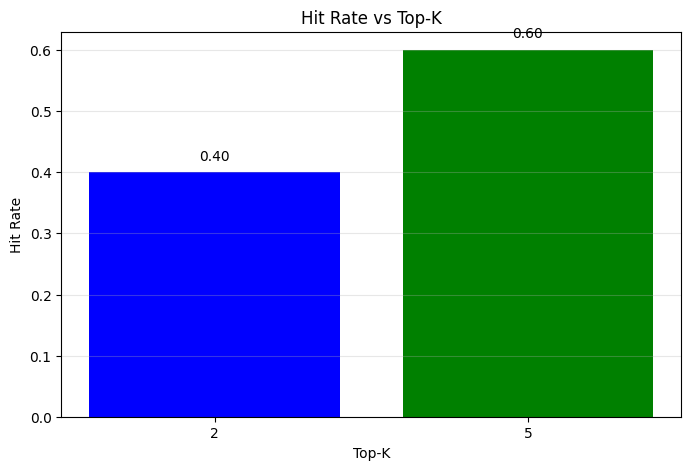


Experiment complete. Larger top_k improves recall but may add noise.


In [6]:
print("=== Parameter Comparison Experiment ===")
print("Comparing top_k = 2 vs top_k = 5\n")

top_k_values = [2, 5]
experiment_results = []

for k in top_k_values:
    hits_k = 0
    for q in control_queries:
        results = search_faiss(q['query'], index, vectorizer, svd, top_k=k)
        retrieved_doc_ids = [r['doc_id'] for r in results]
        if q['expected_doc_id'] in retrieved_doc_ids:
            hits_k += 1

    hit_rate = hits_k / len(control_queries)
    experiment_results.append({'top_k': k, 'hit_rate': hit_rate})
    print(f"top_k={k}: Hit@{k} = {hit_rate:.4f} ({hits_k}/{len(control_queries)})")

plt.figure(figsize=(8, 5))
plt.bar([str(r['top_k']) for r in experiment_results],
        [r['hit_rate'] for r in experiment_results],
        color=['blue', 'green'])
plt.title('Hit Rate vs Top-K')
plt.xlabel('Top-K')
plt.ylabel('Hit Rate')
for i, r in enumerate(experiment_results):
    plt.text(i, r['hit_rate'] + 0.02, f"{r['hit_rate']:.2f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"))
plt.show()

print(f"\nExperiment complete. Larger top_k improves recall but may add noise.")

In [7]:
print("=== Knowledge Base Update ===")

old_eval_results = eval_results.copy()

new_documents = [
    {
        "id": 11,
        "title": "Как работать с инфлюенсер-маркетингом?",
        "content": "Инфлюенсер-маркетинг — это продвижение бренда через лидеров мнений в социальных сетях и блогах. Эффективность зависит от релевантности аудитории блогера, качества контента и уровня доверия подписчиков. Важные этапы: поиск подходящих авторов, согласование ТЗ, запуск интеграции и анализ метрик (охват, вовлеченность, переходы, промокод-продажи)."
    },
    {
        "id": 12,
        "title": "Что такое сквозная аналитика?",
        "content": "Сквозная аналитика объединяет данные из рекламных кабинетов, CRM-систем и сайта для отслеживания полного пути клиента от первого клика до повторной покупки. Позволяет точно рассчитывать ROI по каждому каналу, ключевому слову и объявлению. Реализуется через интеграцию Google Analytics, Яндекс.Метрики и CRM с использованием UTM-разметки и систем атрибуции."
    },
    {
        "id": 13,
        "title": "Как повысить конверсию сайта (CRO)?",
        "content": "Оптимизация конверсии (CRO) — это процесс улучшения пользовательского опыта сайта для увеличения доли посетителей, совершающих целевые действия. Включает A/B-тестирование элементов, упрощение форм, улучшение навигации, добавление социальных доказательств и оптимизацию скорости загрузки. Регулярный анализ тепловых карт и поведения пользователей помогает находить узкие места."
    }
]

print(f"Added {len(new_documents)} new documents")

updated_knowledge_base = knowledge_base + new_documents

updated_chunks = chunk_documents(updated_knowledge_base, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
updated_chunk_texts = [chunk['content'] for chunk in updated_chunks]

new_vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
new_tfidf_matrix = new_vectorizer.fit_transform(updated_chunk_texts)

new_svd = TruncatedSVD(n_components=EMBEDDING_DIM, random_state=SEED)
new_embeddings = new_svd.fit_transform(new_tfidf_matrix)
new_embeddings = normalize(new_embeddings)

new_index = faiss.IndexFlatIP(new_embeddings.shape[1])
new_index.add(new_embeddings)

print(f"Re-indexed: {len(updated_chunks)} chunks")
print(f"Embedding dimension: {new_embeddings.shape[1]}")

print(f"\n=== Retrieval Before vs After Update ===")

update_test_queries = [
    "What is influencer marketing?",
    "How does cross-channel analytics work?",
    "How to improve website conversion rate?"
]

update_comparison = []

for query in update_test_queries:
    query_tfidf_old = vectorizer.transform([query])
    query_emb_old = svd.transform(query_tfidf_old)
    query_emb_old = normalize(query_emb_old)

    _, indices_old = index.search(query_emb_old, 3)
    old_sources = [f"Doc_{chunks[idx]['doc_id']}" for idx in indices_old[0]]

    query_tfidf_new = new_vectorizer.transform([query])
    query_emb_new = new_svd.transform(query_tfidf_new)
    query_emb_new = normalize(query_emb_new)

    _, indices_new = new_index.search(query_emb_new, 3)
    new_sources = [f"Doc_{updated_chunks[idx]['doc_id']}" for idx in indices_new[0]]

    changed = old_sources != new_sources

    update_comparison.append({
        'query': query,
        'before_retrieved_sources': '; '.join(old_sources),
        'after_retrieved_sources': '; '.join(new_sources),
        'changed': changed
    })

    print(f"\nQuery: {query}")
    print(f"  Before: {old_sources}")
    print(f"  After:  {new_sources}")
    print(f"  Changed: {changed}")

update_df = pd.DataFrame(update_comparison)
update_df.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv"), index=False)
print(f"\nSaved retrieval_before_after_update.csv")

=== Knowledge Base Update ===
Added 3 new documents
Re-indexed: 18 chunks
Embedding dimension: 10

=== Retrieval Before vs After Update ===

Query: What is influencer marketing?
  Before: ['Doc_3', 'Doc_2', 'Doc_1']
  After:  ['Doc_3', 'Doc_2', 'Doc_1']
  Changed: False

Query: How does cross-channel analytics work?
  Before: ['Doc_13', 'Doc_7', 'Doc_15']
  After:  ['Doc_13', 'Doc_12', 'Doc_7']
  Changed: True

Query: How to improve website conversion rate?
  Before: ['Doc_3', 'Doc_2', 'Doc_1']
  After:  ['Doc_3', 'Doc_2', 'Doc_1']
  Changed: False

Saved retrieval_before_after_update.csv


In [8]:
def mini_rag(query: str, index: faiss.Index, vectorizer: TfidfVectorizer,
             svd: TruncatedSVD, top_k: int = 2) -> Dict:
    """Простой RAG конвейер"""
    results = search_faiss(query, index, vectorizer, svd, top_k=top_k)

    context_parts = []
    sources = []
    for r in results:
        context_parts.append(f"[{r['doc_title']}]: {r['content']}")
        sources.append(r['doc_title'])

    context = '\n\n'.join(context_parts)

    if context:
        answer = f"Based on the retrieved information:\n\n{context}\n\n"
        answer += f"**Sources:** {', '.join(sources)}"
    else:
        answer = "No relevant information found in the knowledge base."
        sources = []

    return {
        'question': query,
        'answer': answer,
        'retrieved_sources': '; '.join(sources),
        'context': context
    }

print("=== Mini-RAG Examples ===\n")

rag_queries = [
    "How to improve SEO ranking?",
    "What is content marketing strategy?",
    "How to set up targeted advertising?",
    "How to automate email marketing?",
    "How to optimize website conversion rate?"
]

rag_results = []

for i, query in enumerate(rag_queries):
    print(f"--- Example {i+1} ---")
    result = mini_rag(query, index, vectorizer, svd, top_k=2)

    print(f"Question: {query}")
    print(f"Answer (truncated): {result['answer'][:200]}...")
    print(f"Sources: {result['retrieved_sources']}")
    print()

    rag_results.append({
        'question': query,
        'answer': result['answer'][:500],
        'retrieved_sources': result['retrieved_sources']
    })

rag_df = pd.DataFrame(rag_results)
rag_df.to_csv(os.path.join(ARTIFACTS_DIR, "rag_examples.csv"), index=False)
print(f"Saved rag_examples.csv ({len(rag_df)} examples)")

=== Mini-RAG Examples ===

--- Example 1 ---
Question: How to improve SEO ranking?
Answer (truncated): Based on the retrieved information:

[Как работает поисковая оптимизация (SEO)?]: SEO (Search Engine Optimization) — это процесс улучшения видимости сайта в органических результатах поисковых систем, ...
Sources: Как работает поисковая оптимизация (SEO)?; Что такое цифровой маркетинг?

--- Example 2 ---
Question: What is content marketing strategy?
Answer (truncated): Based on the retrieved information:

[Как работает поисковая оптимизация (SEO)?]: SEO (Search Engine Optimization) — это процесс улучшения видимости сайта в органических результатах поисковых систем, ...
Sources: Как работает поисковая оптимизация (SEO)?; Что такое цифровой маркетинг?

--- Example 3 ---
Question: How to set up targeted advertising?
Answer (truncated): Based on the retrieved information:

[Как работает поисковая оптимизация (SEO)?]: SEO (Search Engine Optimization) — это процесс улучшения видимости сайта 

In [9]:
print("=== Error Analysis ===\n")

errors = [r for r in eval_results if r['hit_at_k'] == 0]

print(f"Total queries: {len(eval_results)}")
print(f"Failed retrievals: {len(errors)}")
print(f"Success rate: {(len(eval_results) - len(errors)) / len(eval_results) * 100:.1f}%\n")

if errors:
    print("=== Failed Retrieval Examples ===\n")
    for i, err in enumerate(errors[:3]):
        print(f"Error {i+1}:")
        print(f"  Query: {err['query']}")
        print(f"  Expected: {err['expected_source']}")
        print(f"  Retrieved: {err['retrieved_sources']}")
        print(f"  Issue: Semantic mismatch or query formulation\n")

print("=== Common Issues ===")
print("1. Query formulation: Some queries use different wording than documents")
print("2. Semantic similarity: TF-IDF may miss semantic relationships")
print("3. Chunk size: Too large chunks may dilute relevant information")
print("4. Knowledge base coverage: Some topics may not be well represented")

print("\n=== Limitations ===")
print("- Simple TF-IDF embeddings (not contextual like BERT)")
print("- No reranking of retrieved results")
print("- Template-based answer generation (not LLM)")
print("- Limited knowledge base size")

=== Error Analysis ===

Total queries: 10
Failed retrievals: 5
Success rate: 50.0%

=== Failed Retrieval Examples ===

Error 1:
  Query: How to use social media for business?
  Expected: Doc_5
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

Error 2:
  Query: How to analyze campaign effectiveness?
  Expected: Doc_7
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

Error 3:
  Query: What is a sales funnel?
  Expected: Doc_8
  Retrieved: Doc_3; Doc_2; Doc_1
  Issue: Semantic mismatch or query formulation

=== Common Issues ===
1. Query formulation: Some queries use different wording than documents
2. Semantic similarity: TF-IDF may miss semantic relationships
3. Chunk size: Too large chunks may dilute relevant information
4. Knowledge base coverage: Some topics may not be well represented

=== Limitations ===
- Simple TF-IDF embeddings (not contextual like BERT)
- No reranking of retrieved results
- Template-based answer ge